<a href="https://colab.research.google.com/github/ArthurTig/Portfolio-de-projetos/blob/main/BodyPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desafio de Integração - ACE**

# **Análise de dados**




In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV


####Funções

In [ ]:
def grafico(x):
  data[x].hist(bins=20)
  plt.title(x)
  plt.xlabel(x)
  plt.ylabel('Frequência')
  plt.show()

def correlacao(data, class_label, x):
    class_column = f'{x}_{class_label}'
    data_one_hot = pd.get_dummies(data, columns=[x], drop_first=False)
    variables_of_interest = [class_column] + data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    correlation_data = data_one_hot[variables_of_interest]
    correlation_matrix = correlation_data.corr()
    correlation_class = correlation_matrix[[class_column]].drop(class_column)
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_class, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlação entre Classe {class_label} e as Variáveis Numéricas')
    plt.show()

def proporcao(total,interesse):
  if total == 0:
    a = 0
  a = interesse*100/total
  return a

def correlacao_numéricas():
  variaveis_numericas = data.select_dtypes(include=['int', 'float'])
  plt.figure(figsize=(10, 8))
  sns.heatmap(variaveis_numericas.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
  plt.title('Matriz de Correlação (Apenas Variáveis Numéricas)')
  plt.show()

def tabelacontingencia(y, x):
  contingency_table = pd.crosstab(data[y], data[x])
  plt.figure(figsize=(8, 6))
  sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
  plt.title('Frequência entre variáveis desejadas' )
  plt.ylabel(y)
  plt.xlabel(x)
  plt.show()

def confusao(modelo,x_test_data,):
  y_pred = modelo.predict(x_test_data)
  y_test_labels = np.argmax(y_test.values, axis=1)
  y_pred_labels = np.argmax(y_pred, axis=1)

  cm = confusion_matrix(y_test_labels, y_pred_labels)

  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  plt.figure(figsize=(8, 6))

  sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
              xticklabels=['Classe A', 'Classe B', 'Classe C', 'Classe D'],
              yticklabels=['Classe A', 'Classe B', 'Classe C', 'Classe D'])
  plt.xlabel("Predição")
  plt.ylabel("Verdadeiro")
  plt.show()

def confusao2(modelo, x_test_data, y_test_data):
  y_pred = modelo.predict(x_test_data)
  y_test_labels = y_test_data.values.ravel()
  y_pred_labels = y_pred

  cm = confusion_matrix(y_test_labels, y_pred_labels)
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  plt.figure(figsize=(8, 6))

  sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
              xticklabels=['Classe 0', 'Classe 1', 'Classe 2', 'Classe 3'],
              yticklabels=['Classe 0', 'Classe 1', 'Classe 2', 'Classe 3'])
  plt.xlabel("Predição")
  plt.ylabel("Verdadeiro")
  plt.show()


## Importando o arquivo csv para iniciar a análise


In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv('bodyPerformance.csv')
data


Saving bodyPerformance.csv to bodyPerformance.csv


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,M,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C
13389,21.0,M,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D
13390,39.0,M,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A
13391,64.0,F,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D


##Analisar variáveis numéricas

Começarei plotando alguns gráficos para vizualizar os dados

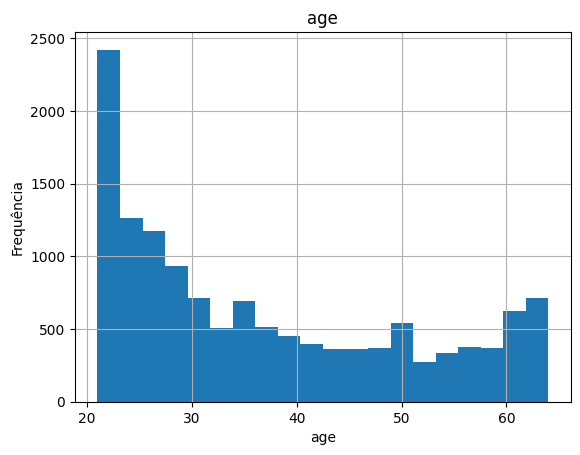

In [ ]:
grafico('age')

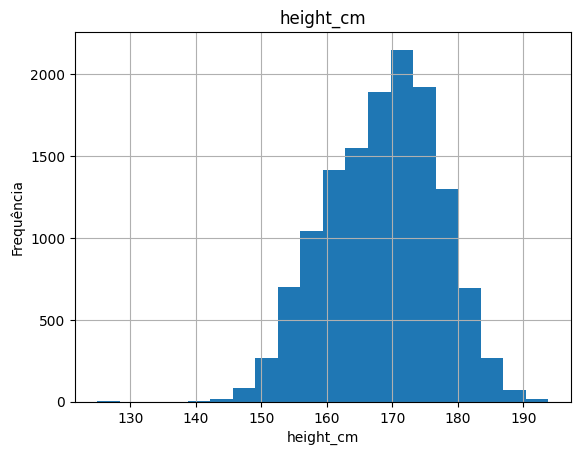

In [ ]:
grafico('height_cm')

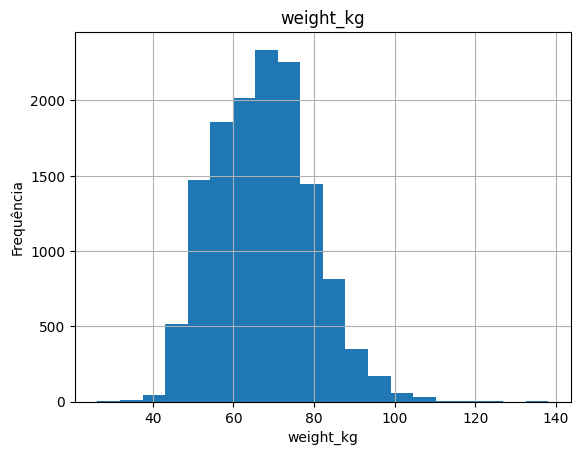

In [ ]:
grafico('weight_kg')

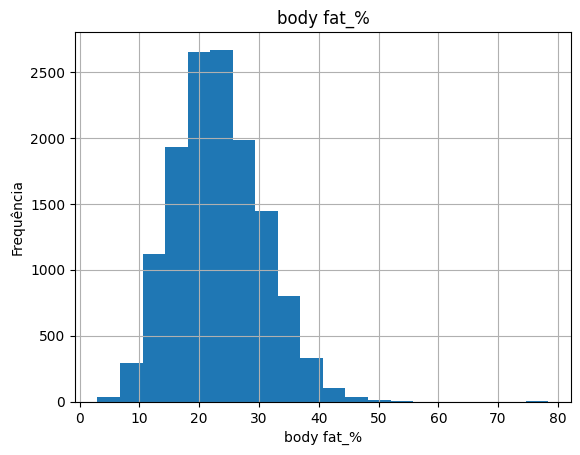

In [ ]:
grafico('body fat_%')

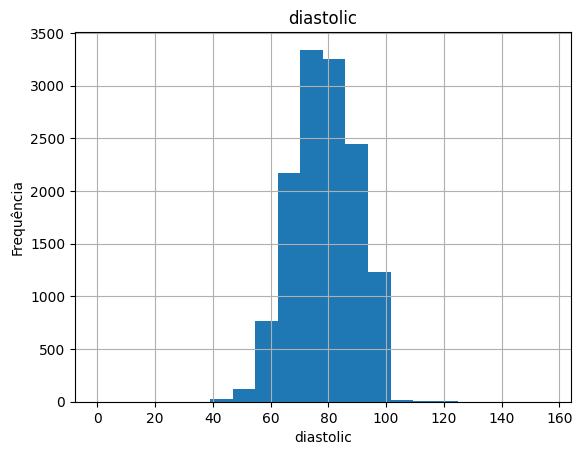

In [ ]:
grafico('diastolic')

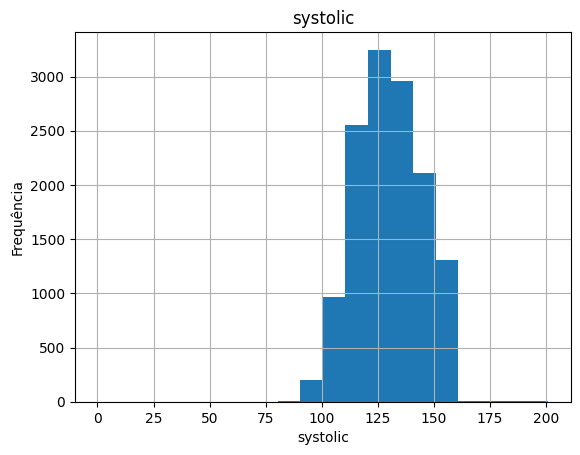

In [ ]:
grafico('systolic')

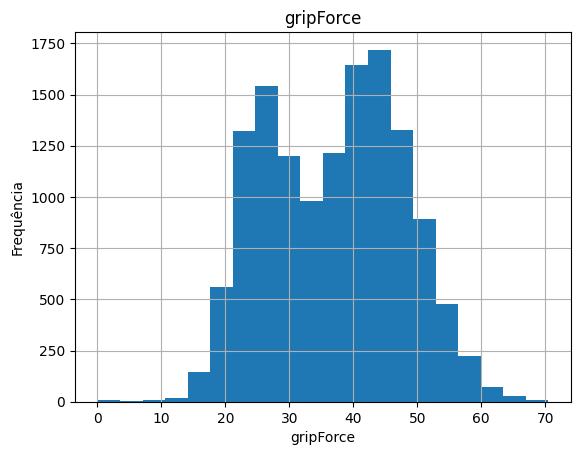

In [ ]:
grafico('gripForce')

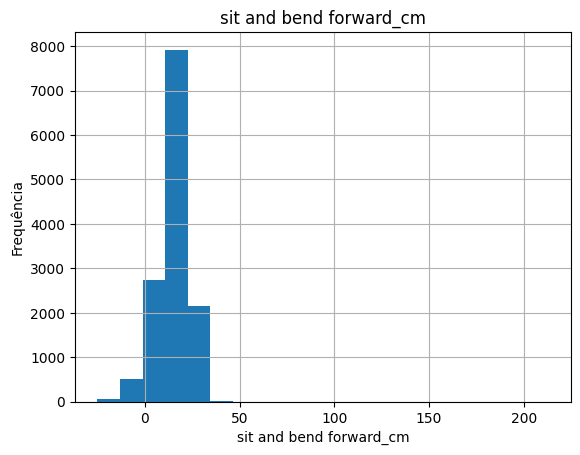

In [ ]:
grafico('sit and bend forward_cm')

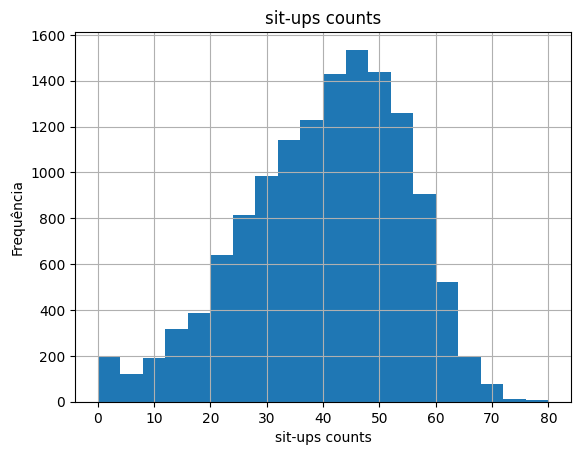

In [ ]:
grafico('sit-ups counts')

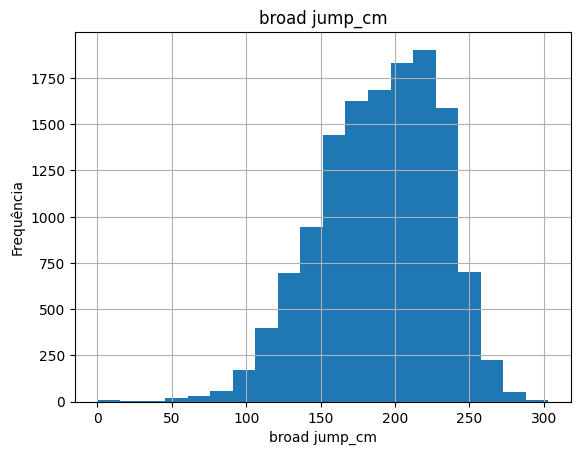

In [ ]:
grafico('broad jump_cm')

* a maioria dos dados possui distribuição aproximadamente normal
* idade e grip force estão mais distribuídos
* na etapa de feature scalling terei que ajustar a escala de alguns dados como sit and bend forward , as pressões ( ver com o Yan para ter certeza)


####Plotarei uma matriz para ver a relação entre as variáveis

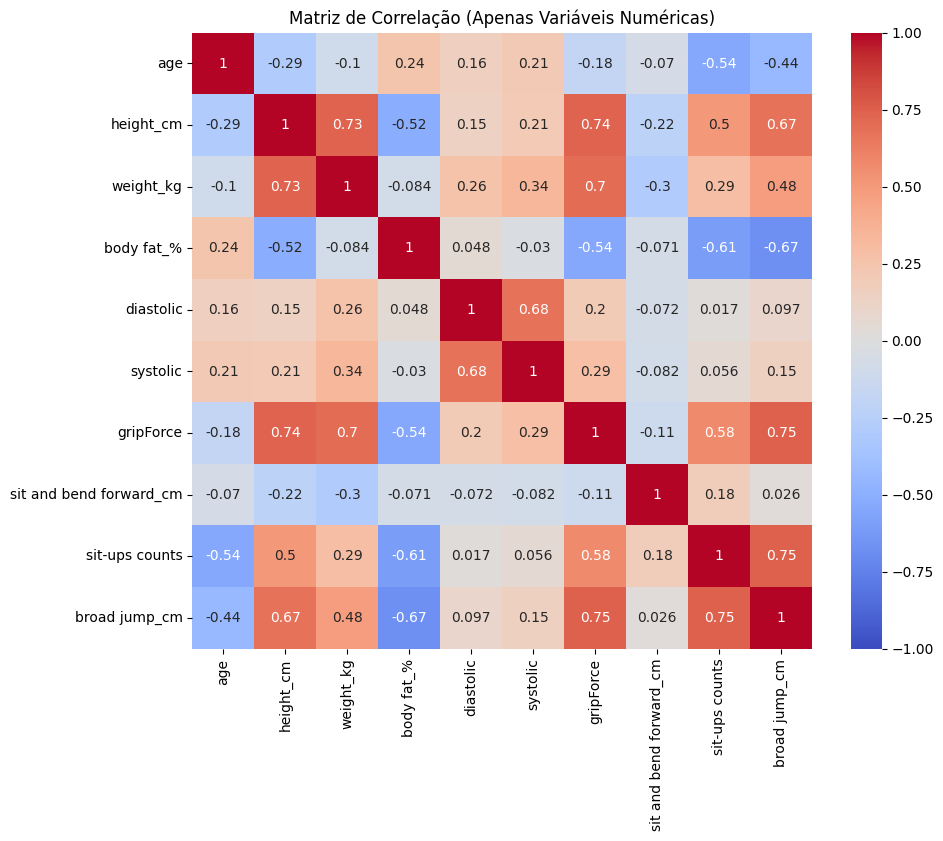

In [ ]:
correlacao_numéricas()

###Observarei agora as variáveis categóricas, gender e class

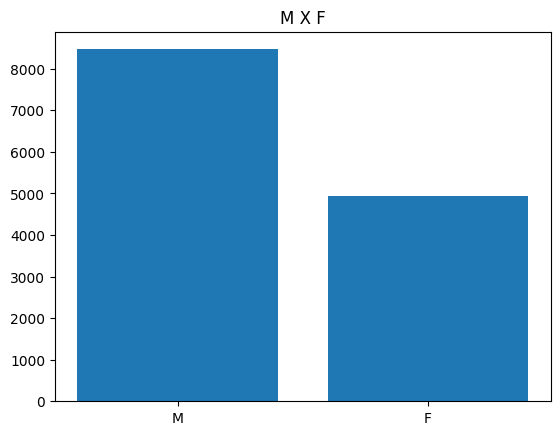

In [ ]:
data_M = data['gender'][data['gender'] == 'M'].count()
data_F = data['gender'][data['gender'] == 'F'].count()
x = [1,2]
plt.title('M X F')
plt.bar(x, height = [data_M , data_F])
plt.xticks(x, ['M', 'F'])
plt.show()


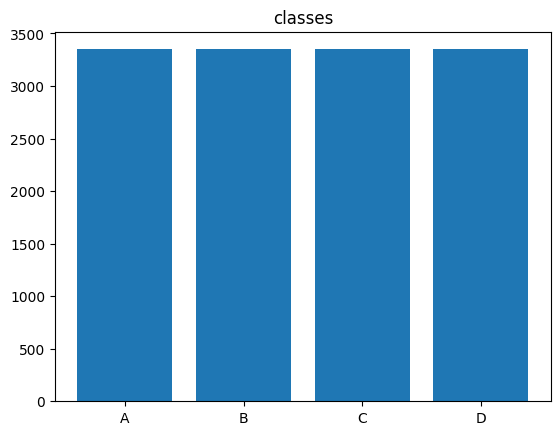

In [ ]:
data_one_hot = pd.get_dummies(data, columns=['class'], drop_first=False)

data_A = data_one_hot['class_A'][data_one_hot['class_A'] == 1].count()
data_B = data_one_hot['class_B'][data_one_hot['class_B'] == 1].count()
data_C = data_one_hot['class_C'][data_one_hot['class_C'] == 1].count()
data_D = data_one_hot['class_D'][data_one_hot['class_D'] == 1].count()

x = [1, 2, 3, 4]
plt.title('classes')
plt.bar(x, height=[data_A, data_B, data_C, data_D])
plt.xticks(x, ['A', 'B', 'C', 'D'])
plt.show()



* Há mais homens do que mulheres
* As classes estão praticamente igualmente distribuídas

###Agora plotarei matrizes de correlação entre as variávais numéricas e o alvo

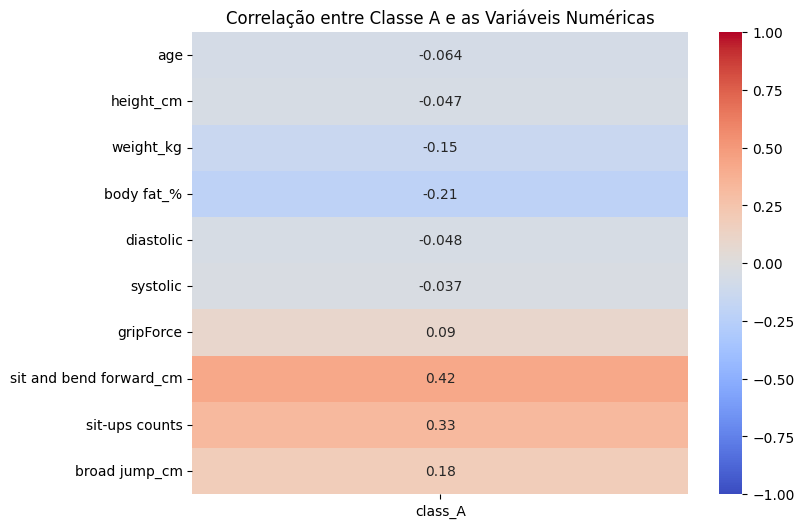

In [ ]:
correlacao(data,'A', 'class')

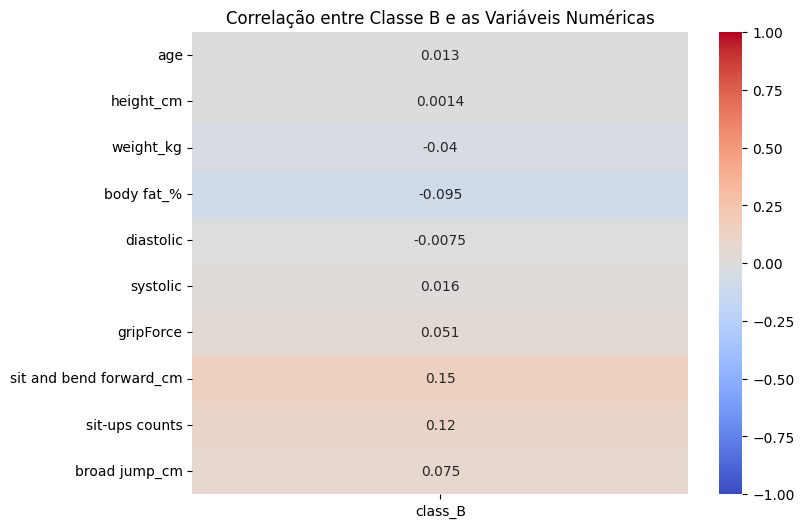

In [ ]:
correlacao(data,'B', 'class')

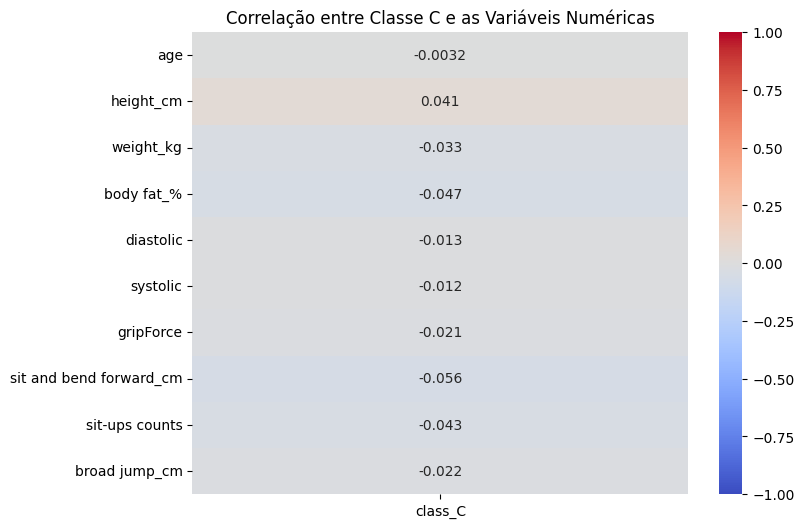

In [ ]:
correlacao(data,'C', 'class')

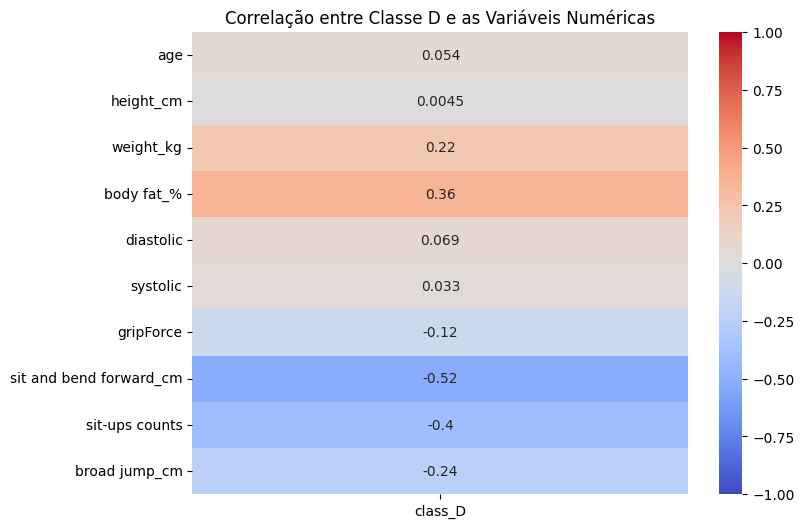

In [ ]:
correlacao(data,'D', 'class')

Observa-se que os atributos que possuem a maior correlação com cada classe são sit and bend forward , body fat e sit up counts.
As classes B e C são bem neutrais , os dados se manifestam em A e D de forma mais expressiva.

###Vou procurar por relações entre gênero e cada uma das variáveis e em seguida entre o gênero e as classes.

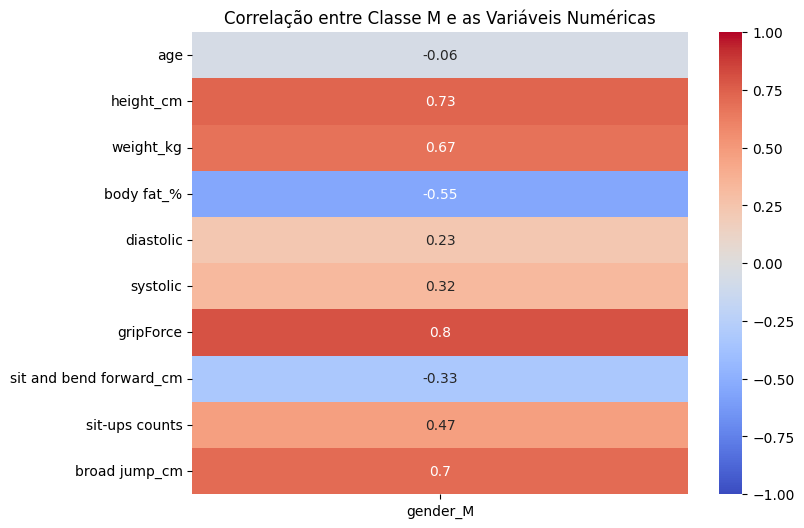

In [ ]:
correlacao(data, 'M', 'gender')

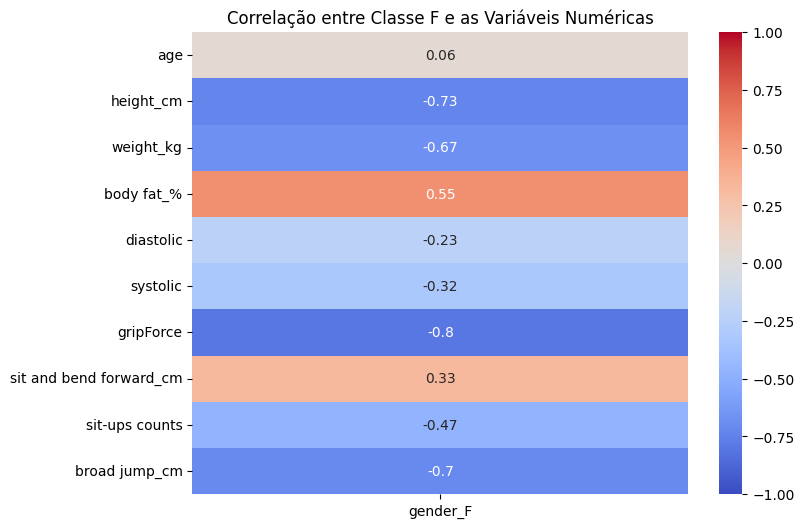

In [ ]:
correlacao(data, 'F', 'gender')

* Achei interessante que a relação entre cada gênero com cada variável é exatamente contrário uma a outra.
* Os homens possuem mais vatagens no quesito físico: grip force, altura, menos BF, pulo. Entretanto a classe que se mostrou mais importante para o sit and bend forward foram as mulheres, apesar dessa relação não ser tão forte assim.
* Vou ver agora correlação entre gênero e o target, proprocionalmente (porque há mais homens) faria sentido ter mais mulheres de classes mais altas? Considerando que elas possuem correlação maior com sit and bend forward.

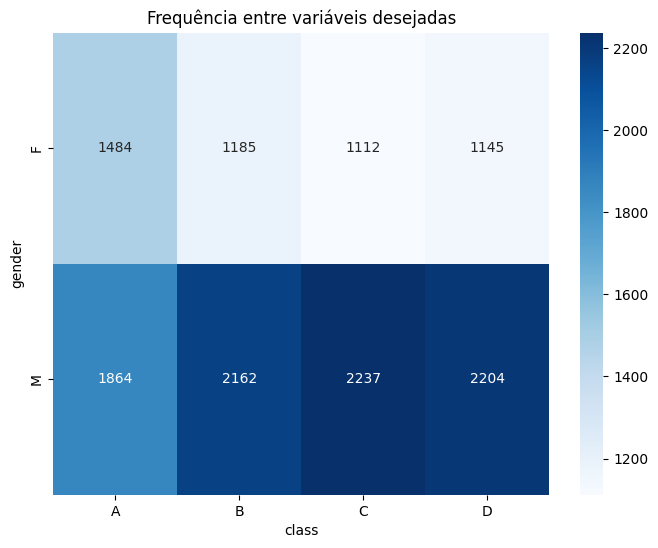

In [ ]:
tabelacontingencia('gender', 'class')
nh = 8467
nm = 4926

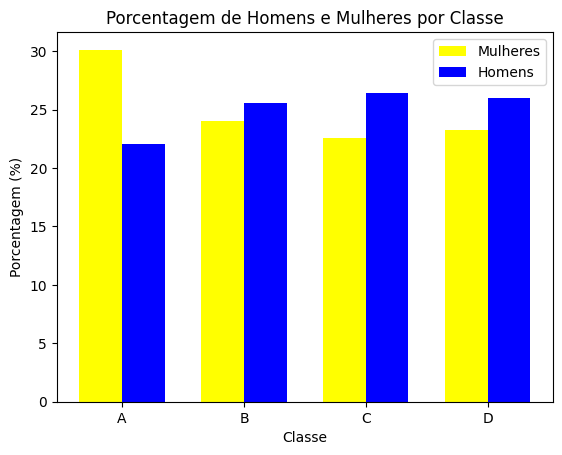

In [ ]:
percent_women = [proporcao(nm,1484), proporcao(nm,1185), proporcao(nm,1112), proporcao(nm,1145)]
percent_men = [proporcao(nh,1864), proporcao(nh,2162), proporcao(nh,2237), proporcao(nh,2204)]

classes = ['A', 'B', 'C', 'D']
x = np.arange(len(classes))
width = 0.35


fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, percent_women, width, label='Mulheres', color='yellow')
bars2 = ax.bar(x + width/2, percent_men, width, label='Homens', color='blue')

ax.set_xlabel('Classe')
ax.set_ylabel('Porcentagem (%)')
ax.set_title('Porcentagem de Homens e Mulheres por Classe')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.show()

* A porcentagem de mulheres classe A ( em relação ao número de mulheres) é um pouco maior que a dos homens (o que faz sentido dada a observação anterior)
* E para as demais classes que são 'menos saudáveis', a proporção de homens aumenta e mulheres diminui

###Verificarei a presença de missing values

In [ ]:
data.isnull().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


Não há missing values (Amém)

#**Processamento dos dados e engenharia de features**

### A primeira etapa é a criação de três novas features

A princípio as novas features criadas serão: diferença de pressão, diferença entre IMC padrão e real e força média.

####**criando a feature de BF ideal**

In [ ]:
homens = {(20,39): (8,20), (40,59): (11,24), (60,120): (13,25)}
mulheres = {(20,39): (18,29), (40,59): (21,32), (60,120): (23,33)}

def classificacao(row, homens, mulheres):
    if row['gender'] == 'M':
        ranges = homens
    else:
        ranges = mulheres

    for age_range, (low, high) in ranges.items():
        if age_range[0] <= row['age'] <= age_range[1]:
            bf = row['body fat_%']

            if bf < low:
                return 'Abaixo do peso'
            elif low <= bf <= high:
                return 'Ideal'
            elif high < bf <= high + 5:
                return 'Acima do peso'
            elif high + 5 < bf <= high + 10:
                return 'Obesidade 1'
            elif high + 10 < bf <= high + 15:
                return 'Obesidade 2'
            else:
                return 'Obesidade Mórbida'

data['bf_categoria'] = data.apply(classificacao, args=(homens, mulheres), axis=1)
data


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,bf_categoria
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,Acima do peso
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,Ideal
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,Acima do peso
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,Ideal
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,Ideal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,M,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,Ideal
13389,21.0,M,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,Ideal
13390,39.0,M,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,Acima do peso
13391,64.0,F,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,Obesidade 1


###**criando a feature de diferença de pressão**

In [ ]:
data['dif_pressao'] = data['systolic'] - data['diastolic']
data.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,bf_categoria,dif_pressao
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,Acima do peso,50.0
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,Ideal,49.0
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,Acima do peso,60.0
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,Ideal,71.0
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,Ideal,57.0


###**criando a feature de força média**

In [ ]:
force_data = data[['broad jump_cm', 'gripForce', 'sit-ups counts']]
scaler = MinMaxScaler(feature_range=(0, 10))
normalized_force_data = scaler.fit_transform(force_data)
data['forca_media'] = normalized_force_data.mean(axis=1)
data

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,bf_categoria,dif_pressao,forca_media
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,Acima do peso,50.0,7.482983
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,Ideal,49.0,6.448625
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,Acima do peso,60.0,6.151069
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,Ideal,71.0,6.575021
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,Ideal,57.0,6.318976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,M,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,Ideal,67.0,5.829223
13389,21.0,M,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,Ideal,54.0,5.397467
13390,39.0,M,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,Acima do peso,54.0,7.396616
13391,64.0,F,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,Obesidade 1,53.0,1.737612


As novas features foram criadas a próxima é etapa é criar mais gráficos e ver a correlação entre elas e as demais.

 #### **Plotando uma matriz de correlação entre cada uma delas com a categoria de BF**

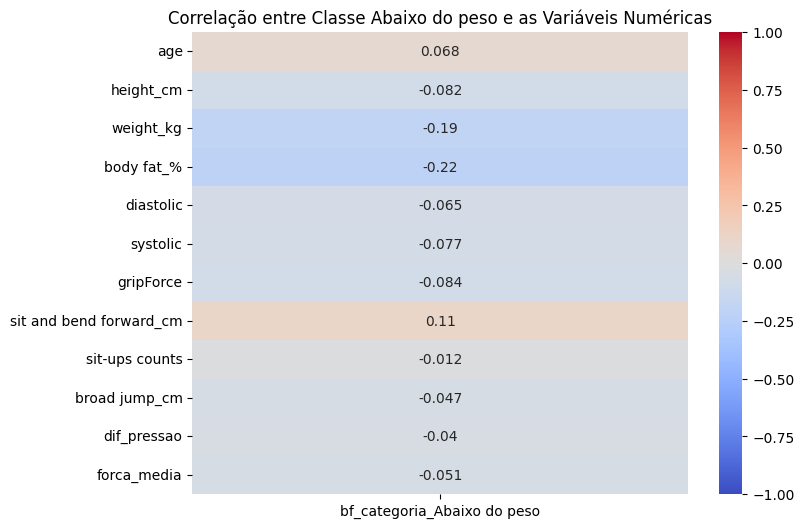

In [ ]:
correlacao(data, 'Abaixo do peso', 'bf_categoria')

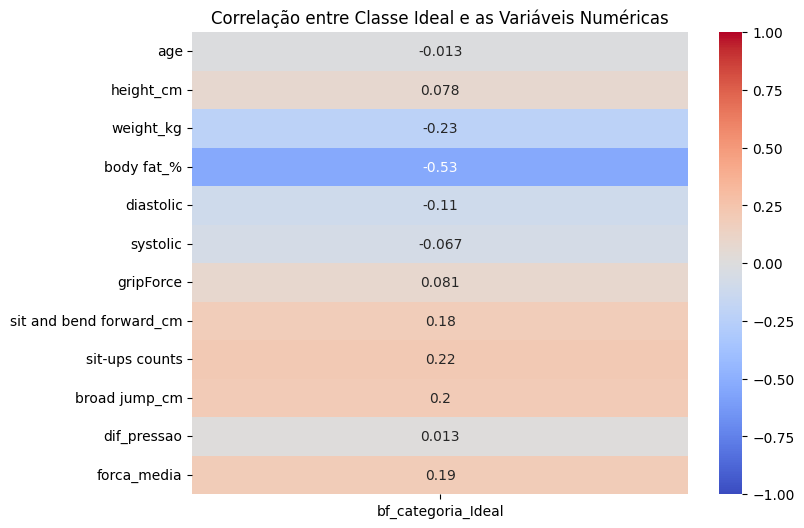

In [ ]:
correlacao(data, 'Ideal', 'bf_categoria')

*   Para esta categoria, os atributos físicos de força, foram os que mais se relacionaram (mesmo sendo pouco)



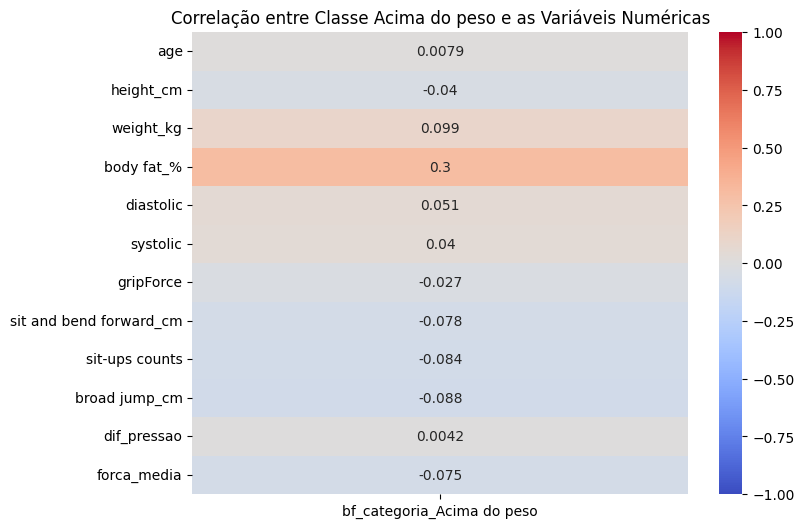

In [ ]:
correlacao(data, 'Acima do peso', 'bf_categoria')

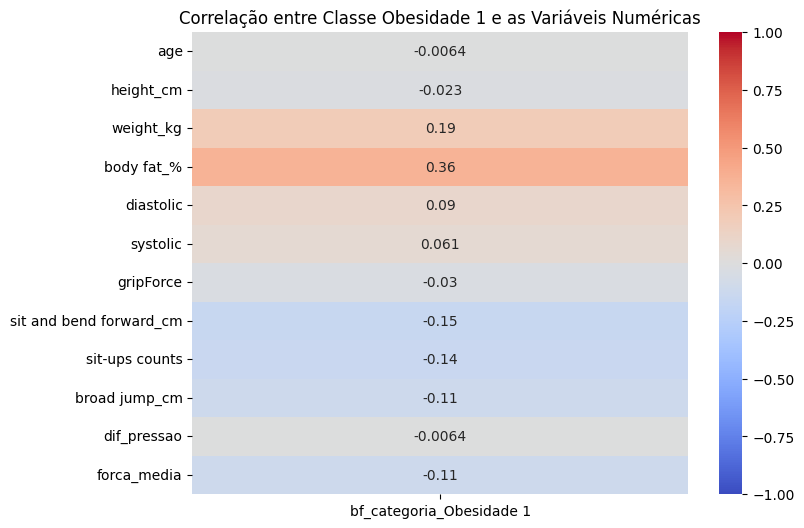

In [ ]:
correlacao(data, 'Obesidade 1', 'bf_categoria')

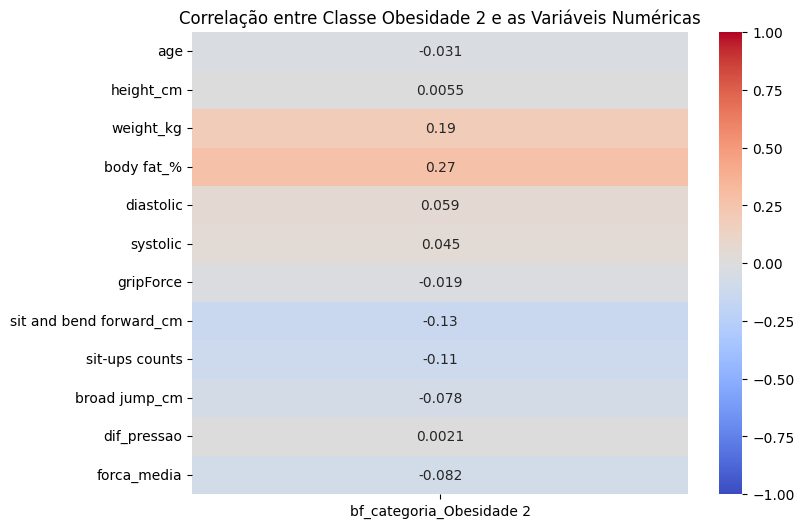

In [ ]:
correlacao(data, 'Obesidade 2', 'bf_categoria')

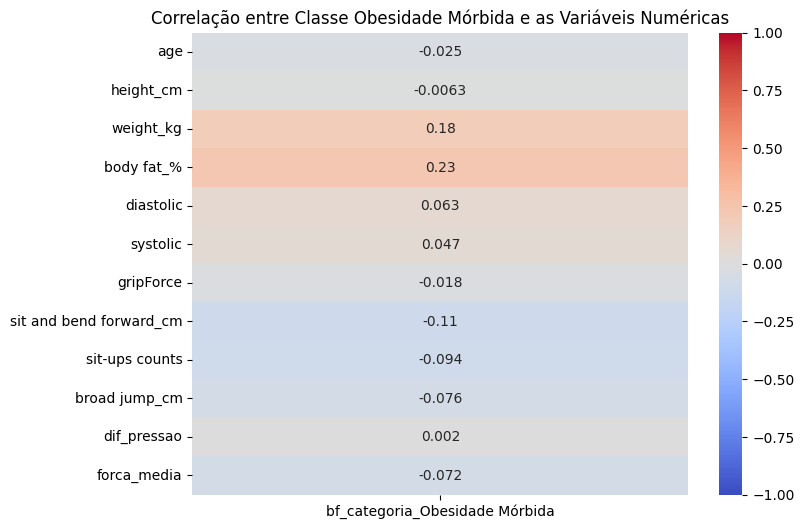

In [ ]:
correlacao(data, 'Obesidade Mórbida', 'bf_categoria')



*   Em todas as categorias, peso e gordura corporal são os que mais se relacionam (o que faz bastante sentido)
*   Mesmo que sendo muito pequeno, de todas as categorias 'sit and bend forward' foi uma das features que mais se relacionou com as outras




#### Agora a correlação entre todas as numéricas

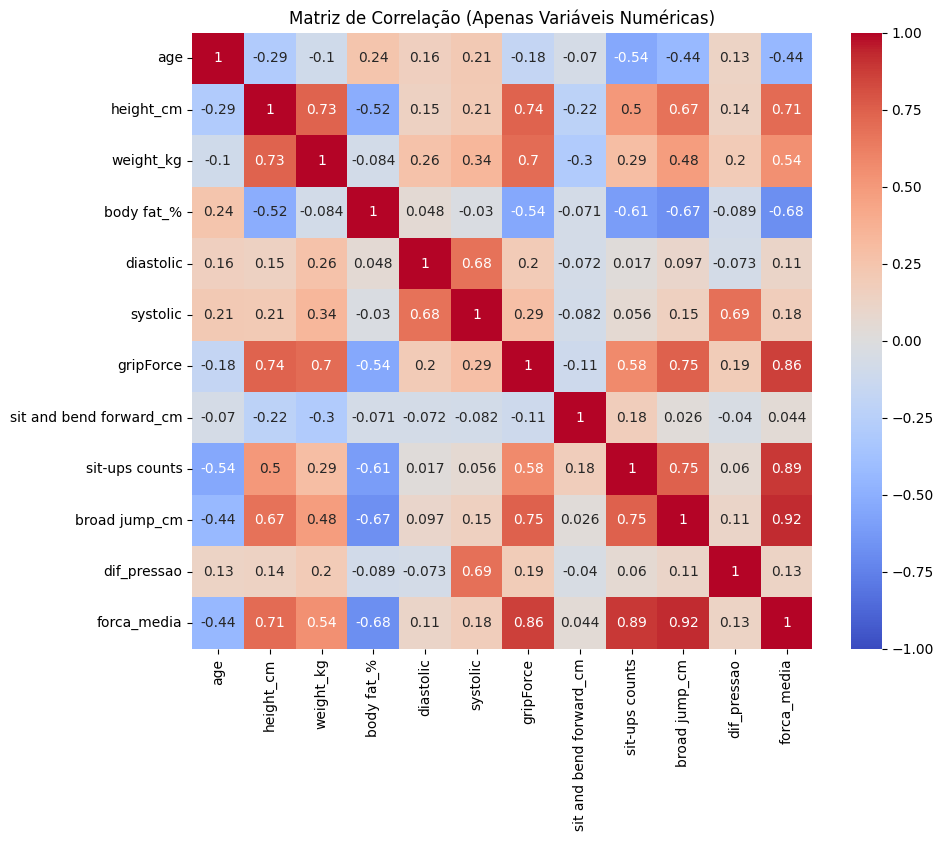

In [ ]:
correlacao_numéricas()



*   Além da relação óbvia da força média com as features de força, também se mostraram  relevantes a idade e o BF(negativamente), altura e peso (positivamente).

*   Diferença de pressão relaciona-se fortemente com a pressão sistólica (o que era esperado) sendo neutra com as demais.

* **Acredito que a adição da feature força média foi importante**

####Agora a relação entre as novas feature numéricas e as classes

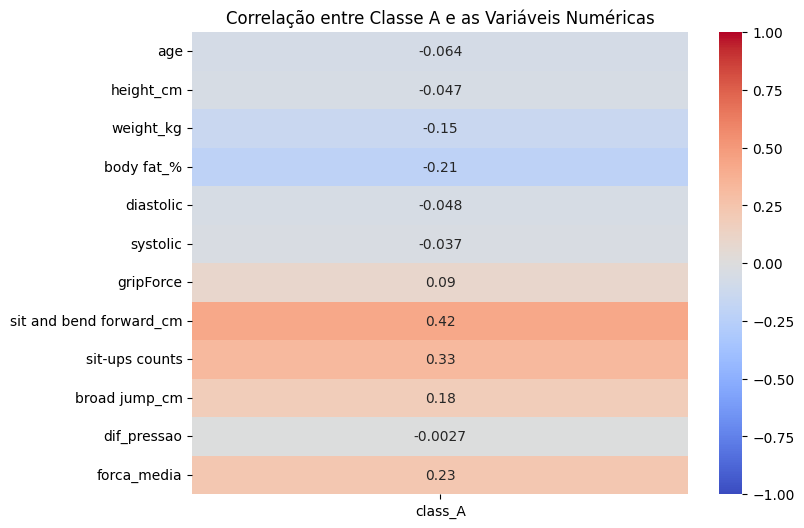

In [ ]:
correlacao(data,'A', 'class')

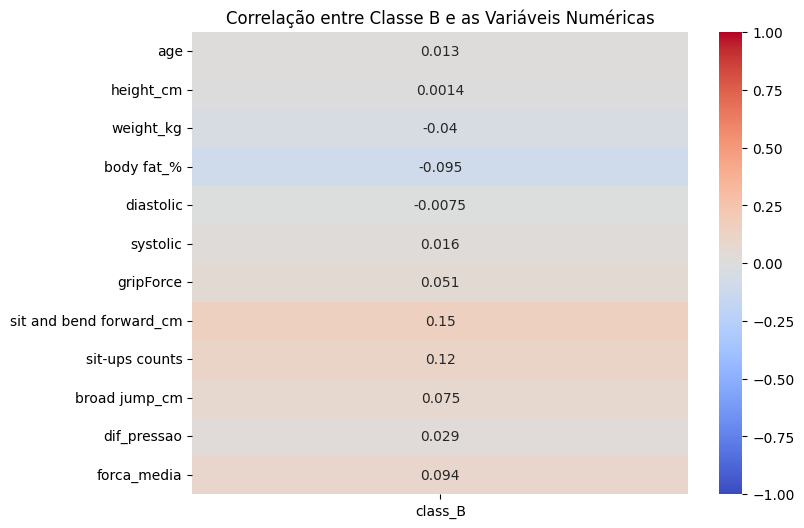

In [ ]:
correlacao(data,'B', 'class')

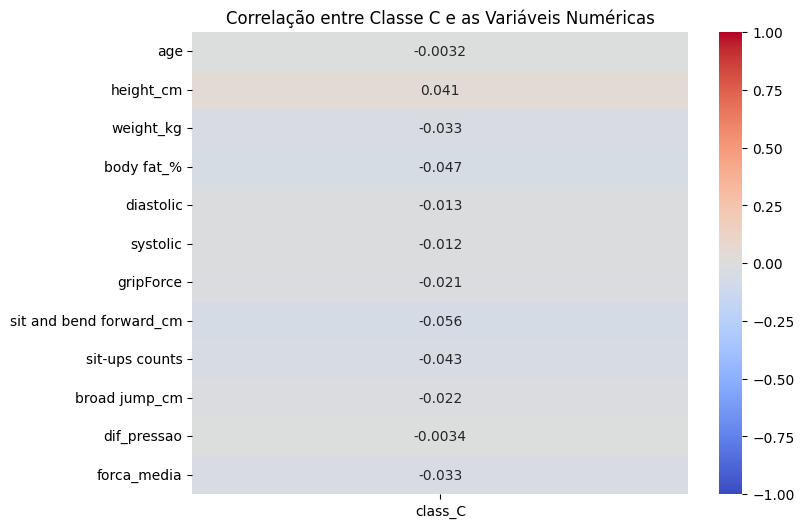

In [ ]:
correlacao(data,'C', 'class')

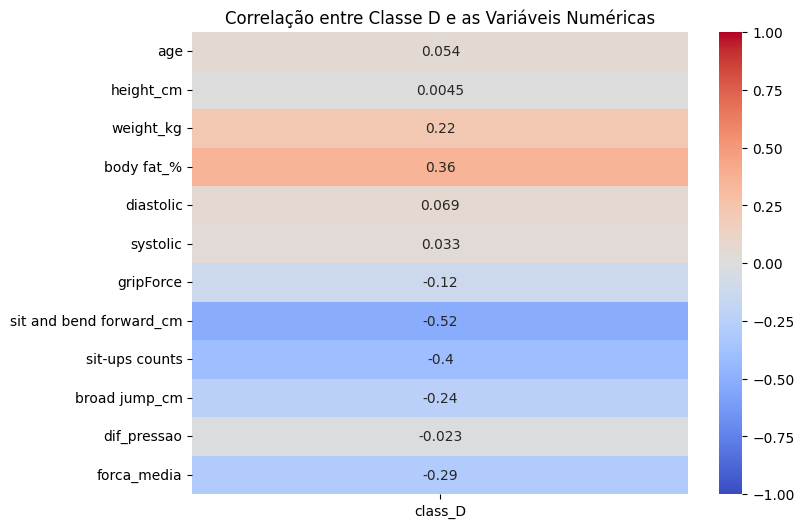

In [ ]:
correlacao(data,'D', 'class')

**Mais uma vez conclui- se que força média é um atributo relevante. Enquanto diferença de pressão se mantém extremamente neutro.**

O objetivo agora é observar a relação entre a nova categórica e as classes (target)

Antes verei como estão distribuídas as novas categorias

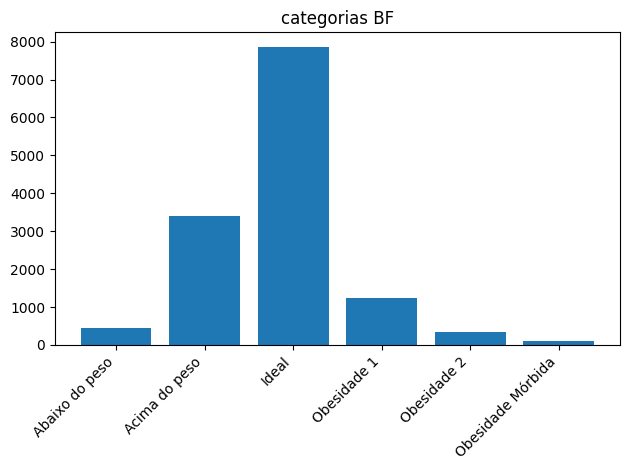

In [ ]:
data_one_hot = pd.get_dummies(data, columns=['bf_categoria'], drop_first=False, prefix='bf_categoria')

bf_categories = [col for col in data_one_hot.columns if col.startswith('bf_categoria_')]
bf_category_values = [col.replace('bf_categoria_', '') for col in bf_categories]

category_counts = {}
for category in bf_category_values:
    category_counts[category] = data_one_hot['bf_categoria_' + category][data_one_hot['bf_categoria_' + category] == 1].count()

counts = list(category_counts.values())

x = range(len(bf_category_values))

plt.title('categorias BF')
plt.bar(x, height=counts)
plt.xticks(x, bf_category_values, rotation=45, ha='right')
plt.tight_layout()
plt.show()

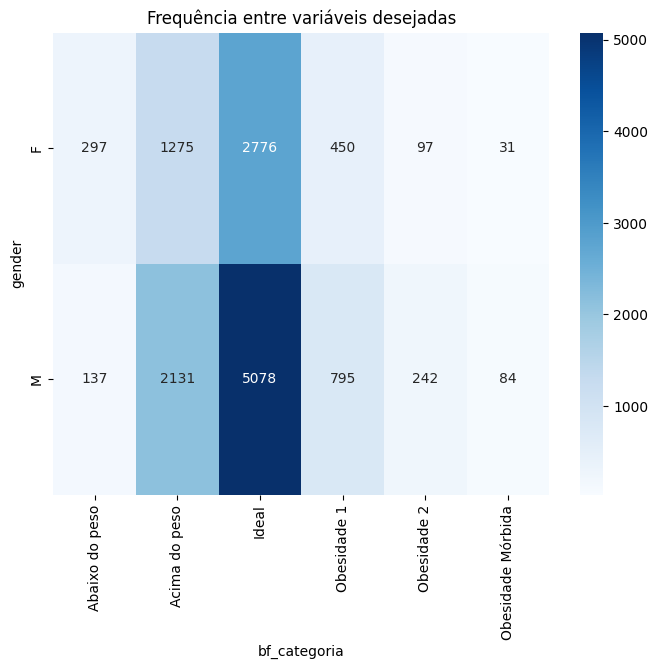

In [ ]:
tabelacontingencia('gender', 'bf_categoria')

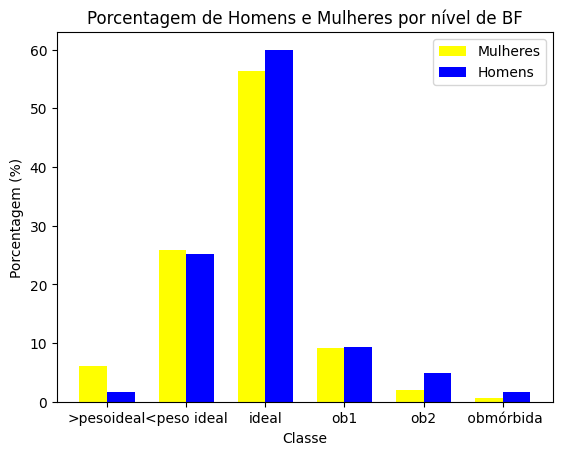

In [ ]:
percent_women = [proporcao(nm,297), proporcao(nm,1275), proporcao(nm,2776), proporcao(nm,450), proporcao(nm,97), proporcao(nm,31)]
percent_men = [proporcao(nh,137), proporcao(nh,2131), proporcao(nh,5078), proporcao(nh,795), proporcao(nm,242), proporcao(nm,84)]

categorias = ['>pesoideal', '<peso ideal', 'ideal', 'ob1', 'ob2', ' obmórbida']
x = np.arange(len(categorias))  # posições para as barras
width = 0.35  # largura das barras

# Plotando o gráfico
fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, percent_women, width, label='Mulheres', color='yellow')
bars2 = ax.bar(x + width/2, percent_men, width, label='Homens', color='blue')

# Adicionando detalhes
ax.set_xlabel('Classe')
ax.set_ylabel('Porcentagem (%)')
ax.set_title('Porcentagem de Homens e Mulheres por nível de BF')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()

plt.show()

Há mais homens obesos em quantidade e porcentagem, mas á mais mulheres em porcentagem acima e abaixo do peso enquanto percentualmente há mais homens no nível ideal.

### Por último a relação entre a nova categórica e as classes

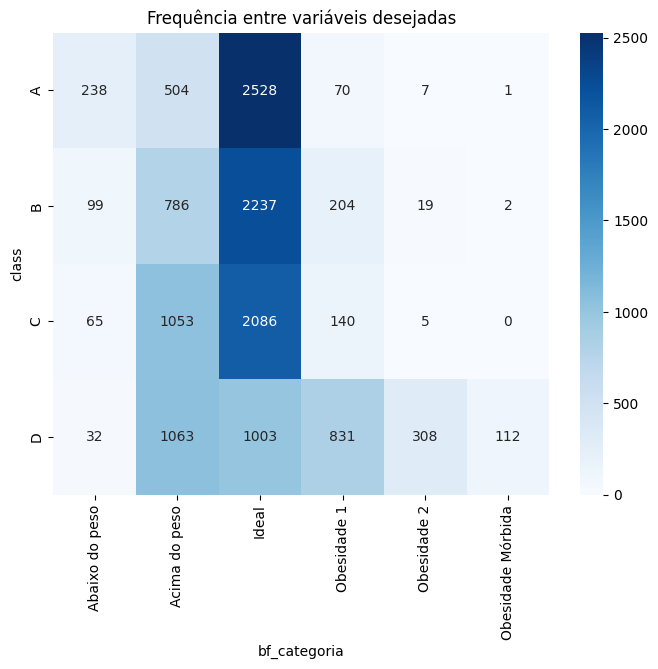

In [ ]:
tabelacontingencia('class', 'bf_categoria')

*   **Como esperado, a maioria das pessoas na classe A estão com peso ideal, e na classe D, a maioria são aquelas que estão com sobrepeso ou alguma obesidade  **
* Interessante observar como quase todos os obesos estão na classe D  (perguntar pro ROK se não faz sentido deixar só uma obesidade, ou o fato de haver um número considerável de obesos tipo 1 nas demais classes mudas isso???)


### **Nesse momento tornarei as variáveis class, gender e bf_categoria em variáveis numéricas, criando colunas binárias.**

In [ ]:
data = pd.get_dummies(data, columns=['gender'], drop_first=False, dtype=int)
data.loc[:, data.columns.str.startswith('gender')] = data.loc[:, data.columns.str.startswith('gender')].astype(int)
data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,bf_categoria,dif_pressao,forca_media,gender_F,gender_M
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,Acima do peso,50.0,7.482983,0,1
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,Ideal,49.0,6.448625,0,1
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,Acima do peso,60.0,6.151069,0,1
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,Ideal,71.0,6.575021,0,1
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,Ideal,57.0,6.318976,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,Ideal,67.0,5.829223,0,1
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,Ideal,54.0,5.397467,0,1
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,Acima do peso,54.0,7.396616,0,1
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,Obesidade 1,53.0,1.737612,1,0


####**Transformando a coluna class em 4 colunas binárias**

In [ ]:
data = pd.get_dummies(data, columns=['class'], drop_first=False, dtype=int)
data.loc[:, data.columns.str.startswith('class')] = data.loc[:, data.columns.str.startswith('class')].astype(int)
data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,bf_categoria,dif_pressao,forca_media,gender_F,gender_M,class_A,class_B,class_C,class_D
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,Acima do peso,50.0,7.482983,0,1,0,0,1,0
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,Ideal,49.0,6.448625,0,1,1,0,0,0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,Acima do peso,60.0,6.151069,0,1,0,0,1,0
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,Ideal,71.0,6.575021,0,1,0,1,0,0
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,Ideal,57.0,6.318976,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,Ideal,67.0,5.829223,0,1,0,0,1,0
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,Ideal,54.0,5.397467,0,1,0,0,0,1
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,Acima do peso,54.0,7.396616,0,1,1,0,0,0
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,Obesidade 1,53.0,1.737612,1,0,0,0,0,1


####**Transformando a coluna bf_categoria em 6 colunas binárias**

In [ ]:
data = pd.get_dummies(data, columns=['bf_categoria'], drop_first=False, dtype=int)

data.loc[:, data.columns.str.startswith('bf_categoria')] = data.loc[:, data.columns.str.startswith('bf_categoria')].astype(int)
data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,...,class_A,class_B,class_C,class_D,bf_categoria_Abaixo do peso,bf_categoria_Acima do peso,bf_categoria_Ideal,bf_categoria_Obesidade 1,bf_categoria_Obesidade 2,bf_categoria_Obesidade Mórbida
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,...,0,0,1,0,0,1,0,0,0,0
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,...,1,0,0,0,0,0,1,0,0,0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,...,0,0,1,0,0,1,0,0,0,0
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,...,0,1,0,0,0,0,1,0,0,0
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,...,0,0,1,0,0,0,1,0,0,0
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,...,0,0,0,1,0,0,1,0,0,0
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,...,1,0,0,0,0,1,0,0,0,0
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,...,0,0,0,1,0,0,0,1,0,0


### **Dividir o dataset em treino e teste**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(['class_A', 'class_B', 'class_C', 'class_D'], axis = 1), data[['class_A', 'class_B', 'class_C'
, 'class_D']], test_size = 0.2, random_state = 42)

#**Treino e avaliação de modelos**

####Treinando com o modelo "K-Nearest Neighbors"

In [ ]:
KNN = KNeighborsClassifier(n_neighbors = 4)
KNN.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=4)

F1 - Score: 0.45665566924868234


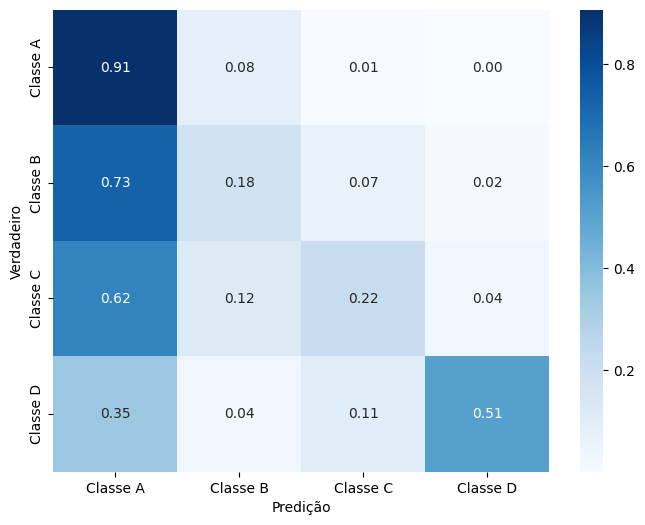

In [ ]:
y_pred = KNN.predict(x_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 - Score:", f1)
confusao(KNN,x_test)



*   O modelo KNN mostrou uma grande taxa de acerto com a classe D
*   A classe A teve um acerto considerável
*   Entretanto, a taxa de detecção em todas as classes foi baixa



####Treinando com o modelo "xgboost"

In [ ]:
XGB = XGBClassifier()
XGB.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

F1 - Score: 0.7274013192554983


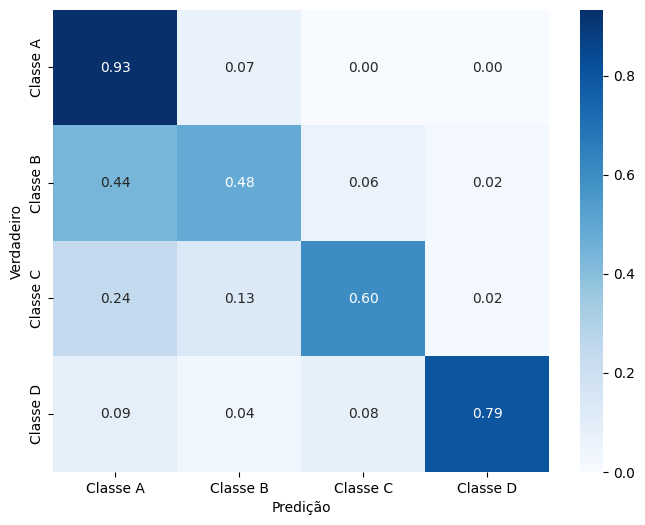

In [ ]:
y_pred = XGB.predict(x_test)
f1 = f1_score(y_test, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao(XGB,x_test)



*   O modelo com XG - Boost teve uma taxa de acerto elevada nas classes A e D
*   Este modelo foi bem mais eficiente que o anterior
*   As classes B e C não são facilmente identificáveis



####Treinando com o modelo "decision tree"

In [ ]:
DT = DecisionTreeClassifier()
DT.fit(x_train, y_train)

DecisionTreeClassifier()

F1 - Score: 0.6465060811104265


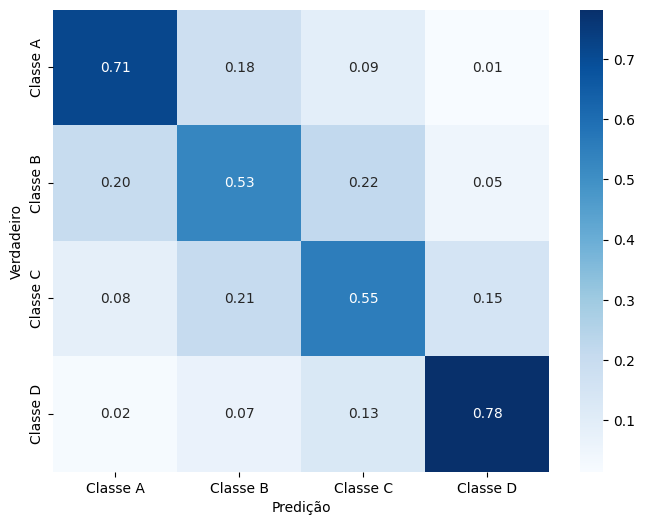

In [ ]:
y_pred = DT.predict(x_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 - Score:", f1)
confusao(DT,x_test)

* o recall foi maior que a precisão na classe D??

* Esse modelo se mostrou mais eficaz que o KNN, mas pior que o XG Boost
* Mas sua pontuação foi mediana
* Novamente observa - se que as classes A e D são mais fáceis de detectar

####Treinando com o modelo "random forest"

In [ ]:
RF = RandomForestClassifier()
RF.fit(x_train, y_train)

RandomForestClassifier()

F1 - Score: 0.6647446820082746


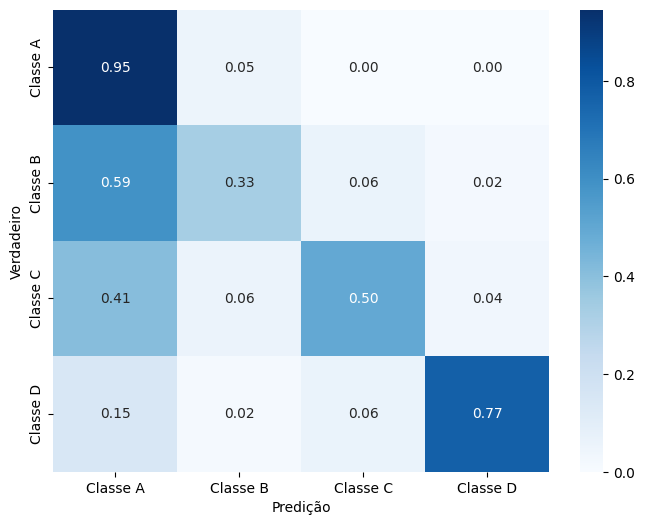

In [ ]:
y_pred = RF.predict(x_test)
f1 = f1_score(y_test, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao(RF,x_test)

* Por enquanto o melhor modelo é o XG - Boost
* Entretanto aquele que teve maior precisão nas classes B e C foi o Decision Tree

####**No geral:**

* O melhor modelo foi o XG Boost.
* Mas Random Forrest foi o mais preciso em classificar a classe A , mas as demais classes deixaram a desejar (destaque para o decision tree que teve um bom desempenho para a classe D também).
* O Decision Tree foi o que melhor desempenhou na classificação das classes B e C , mas as classes A e B deixaram a desejar com um acerto mediano.

###**Neste momento verei como o modelo se comporta se não forem utilizadas as features que criei**

Os passos seguidos serão os mesmos que o modelo anterior apenas retirarei as features criadas


In [ ]:
new_data = data.drop(['dif_pressao', 'forca_media', 'bf_categoria_Abaixo do peso', 'bf_categoria_Ideal', 'bf_categoria_Acima do peso', 'bf_categoria_Obesidade 1', 'bf_categoria_Obesidade 2', 'bf_categoria_Obesidade Mórbida'], axis = 1)
new_data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,gender_F,gender_M,class_A,class_B,class_C,class_D
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,0,1,0,0,1,0
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,1,1,0,0,0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,0,1,0,0,1,0
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,0,1,0,1,0,0
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,0,1,0,0,1,0
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,0,1,0,0,0,1
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0,1,1,0,0,0
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,1,0,0,0,0,1


**Dividindo em treino e teste**

In [ ]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(new_data.drop(['class_A', 'class_B', 'class_C', 'class_D'], axis = 1), new_data[['class_A', 'class_B', 'class_C'
, 'class_D']], test_size = 0.2, random_state = 42)

####**Testando para o novo dataset**

In [ ]:
KNN = KNeighborsClassifier(n_neighbors = 4)
KNN.fit(x_train1, y_train1)

KNeighborsClassifier(n_neighbors=4)

F1 - Score: 0.4671855847158905


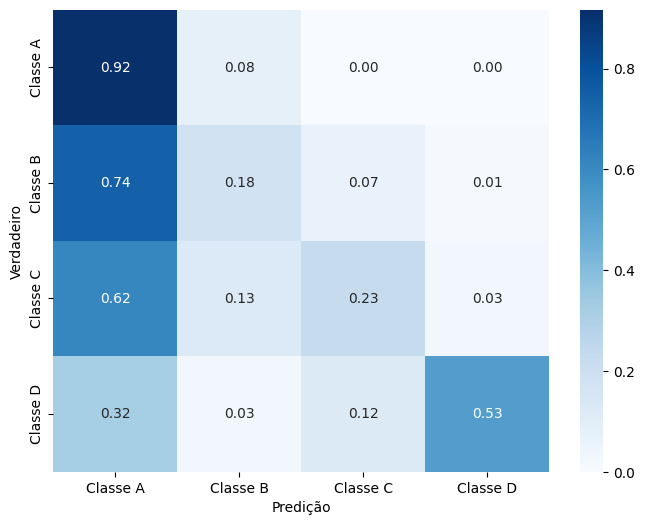

In [ ]:
y_pred = KNN.predict(x_test1)
f1 = f1_score(y_test1, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao(KNN, x_test1)

In [ ]:
XGB = XGBClassifier()
XGB.fit(x_train1, y_train1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

F1 - Score: 0.728136713931935


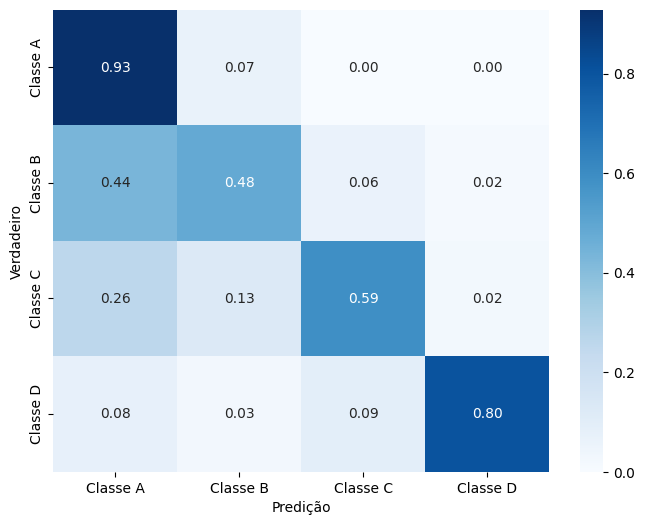

In [ ]:
y_pred = XGB.predict(x_test1)
f1 = f1_score(y_test1, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao(XGB, x_test1)

In [ ]:
DT = DecisionTreeClassifier()
DT.fit(x_train1, y_train1)

DecisionTreeClassifier()

F1 - Score: 0.6628442854580694


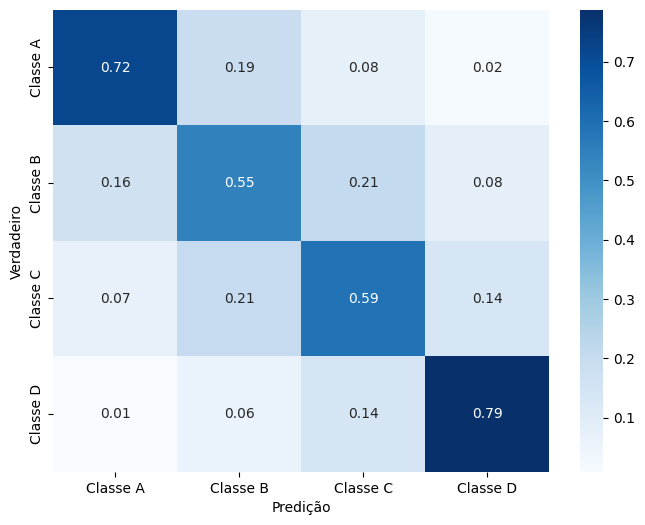

In [ ]:
y_pred = DT.predict(x_test1)
f1 = f1_score(y_test1, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao(DT, x_test1)

In [ ]:
RF = RandomForestClassifier()
RF.fit(x_train1, y_train1)

RandomForestClassifier()

F1 - Score: 0.6788070377320552


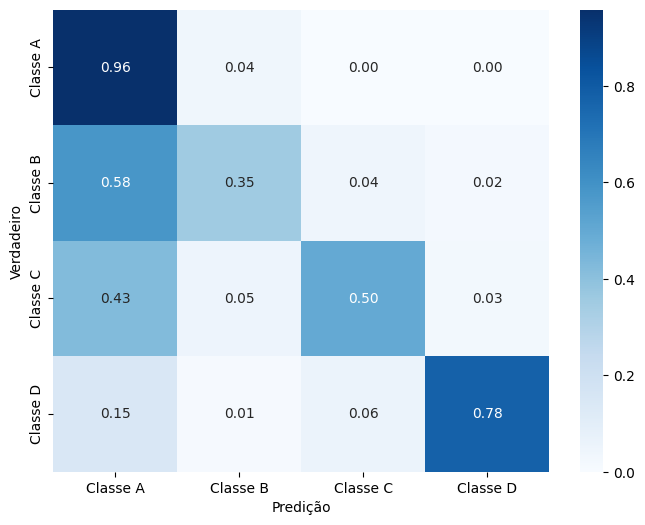

In [ ]:
y_pred = RF.predict(x_test1)
f1 = f1_score(y_test1, y_pred, average='weighted')
print("F1 - Score:", f1)
confusao(RF, x_test1)



*  Todos os modelos sem as features obtiveram desempenho semelhante.
* Aparentemente as features foram uma adição interessante




####**Para o próximo teste, analisarei o comportamento do modelo com o encoding das classes indo de 0 a 4**

Utilizarei os dados sem features.

In [ ]:
new_data['classes'] = new_data[['class_A', 'class_B', 'class_C', 'class_D']].idxmax(axis=1)
new_data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,gender_F,gender_M,class_A,class_B,class_C,class_D,classes
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,0,1,0,0,1,0,class_C
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,1,1,0,0,0,class_A
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,0,1,0,0,1,0,class_C
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,0,1,0,1,0,0,class_B
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,0,1,0,1,0,0,class_B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,0,1,0,0,1,0,class_C
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,0,1,0,0,0,1,class_D
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0,1,1,0,0,0,class_A
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,1,0,0,0,0,1,class_D


In [ ]:
def classe_unica(row):
  if row['classes'] == 'class_A':
    return   0
  elif row['classes'] == 'class_B':
    return   1
  elif row['classes'] == 'class_C':
    return   2
  else:
    return   3
new_data['classse'] = new_data.apply(classe_unica, axis=1)
new_data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,gender_F,gender_M,class_A,class_B,class_C,class_D,classes,classse
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,0,1,0,0,1,0,class_C,2
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,1,1,0,0,0,class_A,0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,0,1,0,0,1,0,class_C,2
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,0,1,0,1,0,0,class_B,1
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,0,1,0,1,0,0,class_B,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,0,1,0,0,1,0,class_C,2
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,0,1,0,0,0,1,class_D,3
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0,1,1,0,0,0,class_A,0
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,1,0,0,0,0,1,class_D,3


In [ ]:
new_data.drop(['class_A', 'class_B', 'class_C', 'class_D', 'classes'], axis = 1, inplace = True)
new_data

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,gender_F,gender_M,classse
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,0,1,2
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,1,0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,0,1,2
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,0,1,1
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,0,1,2
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,0,1,3
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0,1,0
13391,64.0,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,1,0,3


###**Agora testarei os diferentes modelos para esse dataset**

#### **Dividindo em treino e teste **
Criarei um novo conjunto data para futuros testes

In [ ]:
new_data2 = new_data

In [ ]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(new_data.drop(['classse'], axis = 1), new_data[['classse']], test_size = 0.2, random_state = 42)

Treino e teste:

In [ ]:
KNN = KNeighborsClassifier(n_neighbors = 4)
KNN.fit(x_train2, y_train2)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=4)

F1 - Score: 0.5550605820509847


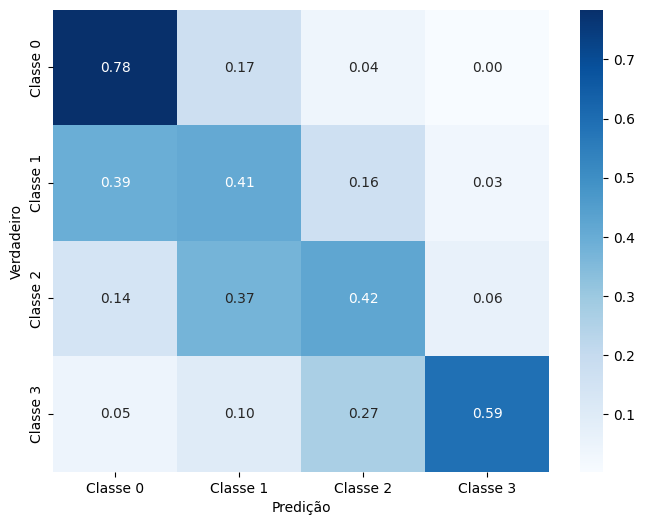

In [ ]:
y_pred = KNN.predict(x_test2)
f1 = f1_score(y_test2, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(KNN, x_test2, y_test2)

In [ ]:
XGB = XGBClassifier()
XGB.fit(x_train2, y_train2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

F1 - Score: 0.7658515155462676


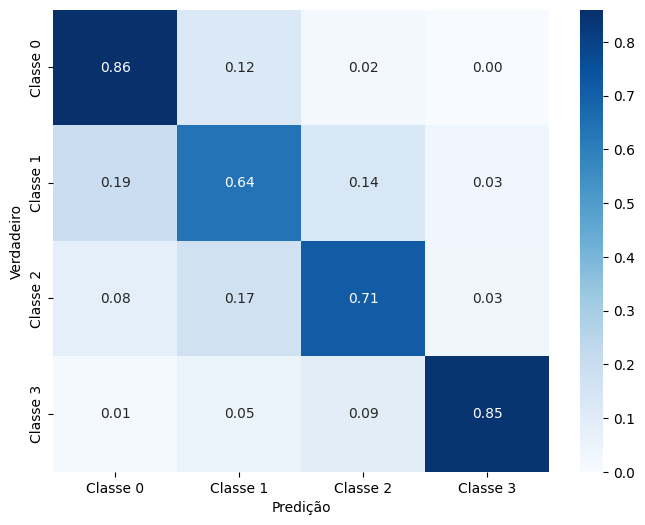

In [ ]:
y_pred = XGB.predict(x_test2)
f1 = f1_score(y_test2, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(XGB, x_test2, y_test2)

In [ ]:
DT = DecisionTreeClassifier()
DT.fit(x_train2, y_train2)

DecisionTreeClassifier()

F1 - Score: 0.6520204409304909


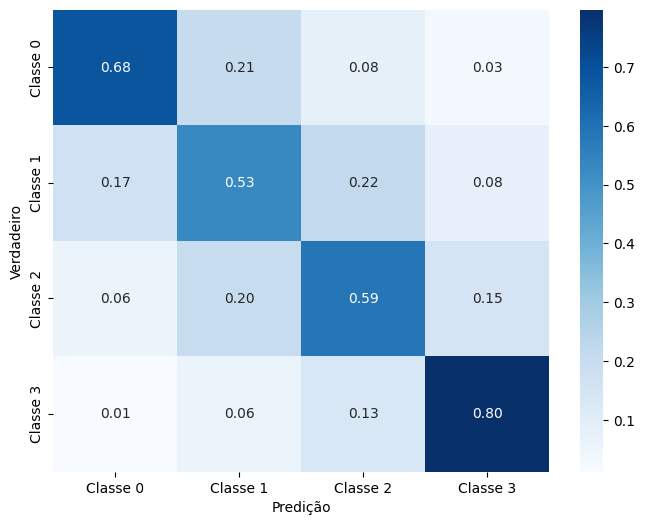

In [ ]:
y_pred = DT.predict(x_test2)
f1 = f1_score(y_test2, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(DT, x_test2, y_test2)

In [ ]:
RF = RandomForestClassifier()
RF.fit(x_train2, y_train2)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

F1 - Score: 0.744454012609289


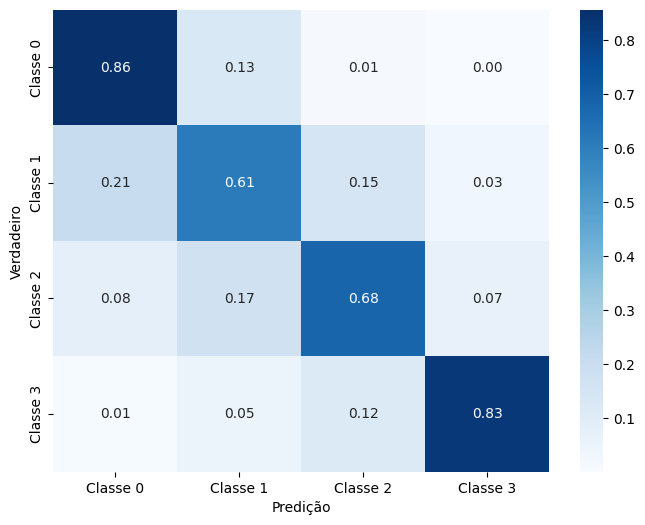

In [ ]:
y_pred = RF.predict(x_test2)
f1 = f1_score(y_test2, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(RF, x_test2, y_test2)

Conclusões

*   Todos os modelos desempenharam melhor com as classes em uma coluna só
*   Importante observar como as classes B e C tiveram uma melhora significativa em todos os modelos.
*   Um dos possíveis motivos para esses dados terem desempenhado melhor é que em uma coluna só, as classes se tornam excludentes(independentes entre si).




### **Tunning de hiperparâmetros**


Como última etapa, tentarei fazer com que o modelo desempenhe melhor, para isso removerei possíveis outliers com a técnica do interquartil.

In [ ]:
def remove_outliers(data,columns):
  for colunas in columns:
    q1 = data[colunas].quantile(0.25)
    q3 = data[colunas].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    data = data[(data[colunas] >= lower_bound) & (data[colunas] <= upper_bound)]
  return data
columns = ['age', 'height_cm', 'weight_kg', 'body fat_%','sit and bend forward_cm',	'sit-ups counts',	'broad jump_cm']
remove_outliers(new_data, columns)

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,gender_F,gender_M,classse
0,27.0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,0,1,2
1,25.0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,1,0
2,31.0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,0,1,2
3,32.0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,0,1,1
4,28.0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13387,39.0,174.4,70.80,24.3,78.0,132.0,41.6,12.0,44.0,168.0,0,1,1
13388,25.0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,0,1,2
13389,21.0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,0,1,3
13390,39.0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,0,1,0


###**Agora testar os modelos com esse dataframe**

Dividindo em treino e teste novamente:

In [ ]:
x_train3,x_test3, y_train3, y_test3 = train_test_split(new_data.drop(['classse'], axis = 1), new_data[['classse']], test_size = 0.2, random_state = 42)

Os modelos:

In [ ]:
KNN = KNeighborsClassifier(n_neighbors = 4)
KNN.fit(x_train3, y_train3)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=4)

F1 - Score: 0.5550605820509847


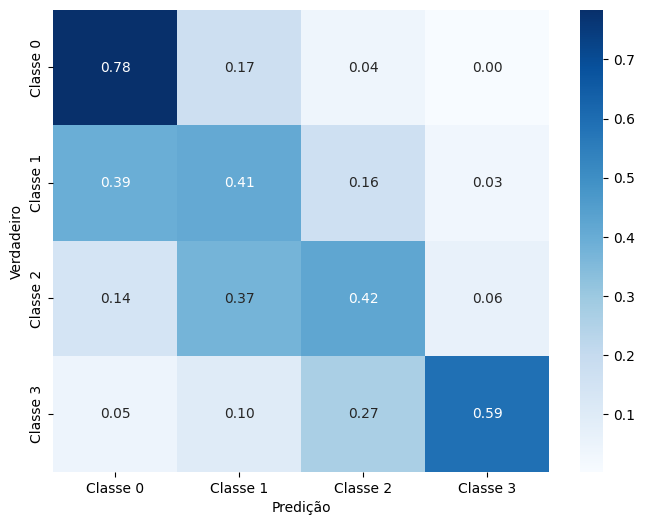

In [ ]:
y_pred = KNN.predict(x_test3)
f1 = f1_score(y_test3, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(KNN, x_test3, y_test3)

In [ ]:
XGB = XGBClassifier()
XGB.fit(x_train3, y_train3)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

F1 - Score: 0.7658515155462676


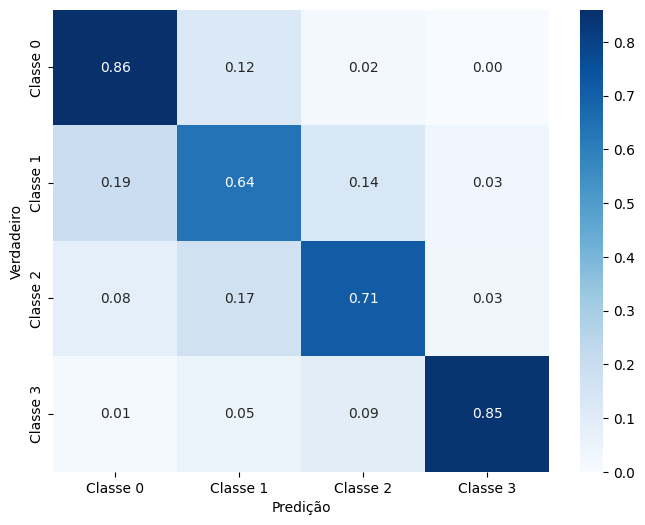

In [ ]:
y_pred = XGB.predict(x_test3)
f1 = f1_score(y_test3, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(XGB, x_test3, y_test3)

In [ ]:
DT = DecisionTreeClassifier()
DT.fit(x_train3, y_train3)

DecisionTreeClassifier()

F1 - Score: 0.6612604611723765


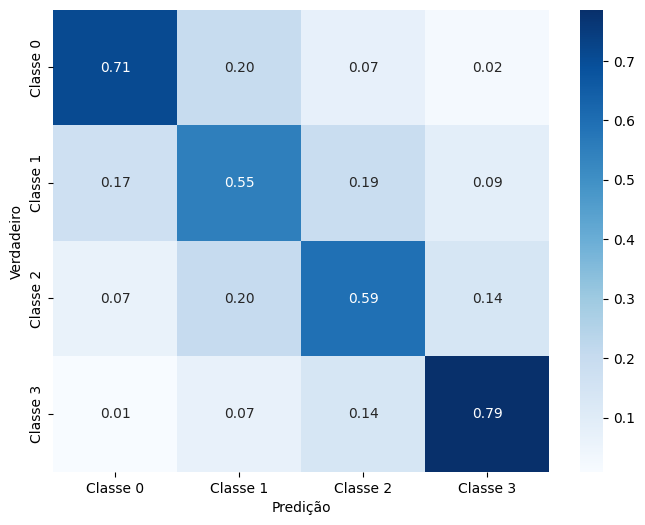

In [ ]:
y_pred = DT.predict(x_test3)
f1 = f1_score(y_test3, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(DT, x_test3, y_test3)

In [ ]:
RF = RandomForestClassifier()
RF.fit(x_train3, y_train3)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

F1 - Score: 0.7504929050145979


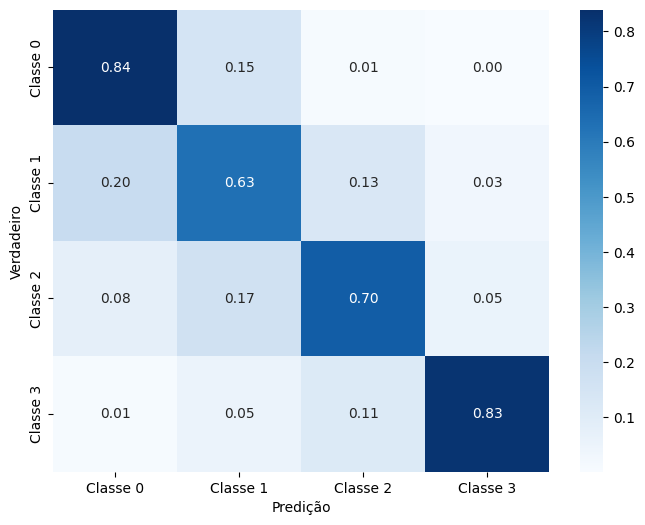

In [ ]:
y_pred = RF.predict(x_test3)
f1 = f1_score(y_test3, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(RF, x_test3, y_test3)


Os modelos não apresentaram grandes mudanças no geral.
Importante notar que a dois modelos obtiveram pontuação acima de 70% no f1-score que é considerado um resultado bom.


###**Utilizarei Grid Search para realizar o tunning de hiperparâmetros e tentar aumentar a eficacia dos modelos**

In [ ]:
parametrosk = {
    'n_neighbors': [4],
    'weights': ['uniform', 'distance', None],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid_search = GridSearchCV(KNN, parametrosk, cv=5)
grid_search.fit(x_train3, y_train3.values.ravel())
print(grid_search.best_params_, grid_search.best_score_)


{'algorithm': 'auto', 'n_neighbors': 4, 'weights': 'distance'} 0.5602010410634934


In [ ]:
y_pred = KNN.predict(x_test3)
acuracia = accuracy_score(y_test3, y_pred)
print('Acurácia:', acuracia)

Acurácia: 0.5543113101903695


KNN apresentou uma breve melhora com o uso do grid search

In [ ]:
parametrosxgb = {'n_estimators': [100, 500],
                 'learning_rate': [0.01, 0.1, 0.3],
                 'max_depth': [3,6,10]
}
grid_search = GridSearchCV(XGB, parametrosxgb, cv=5)
grid_search.fit(x_train3, y_train3.values.ravel())
print(grid_search.best_params_, grid_search.best_score_)

{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100} 0.7452861312513807


In [ ]:
y_pred = XGB.predict(x_test3)
acuracia = accuracy_score(y_test3, y_pred)
print('Acurácia:', acuracia)

Acurácia: 0.7655841731989549


O XG - Boost não apresentou melhora com o grid search

In [ ]:
parametrostree = {'criterion' : ['gini', 'entropy', 'log_loss'],
                  'splitter': ['best', 'random'],
                  'min_samples_split' : [5,10,12],
                  'min_samples_leaf' : [5,10,12]}

grid_search = GridSearchCV(DT, parametrostree, cv=5)
grid_search.fit(x_train3, y_train3.values.ravel())
print(grid_search.best_params_, grid_search.best_score_)

{'criterion': 'gini', 'min_samples_leaf': 12, 'min_samples_split': 10, 'splitter': 'best'} 0.669964006756848


In [ ]:
y_pred = DT.predict(x_test3)
acuracia = accuracy_score(y_test3, y_pred)
print('Acurácia:', acuracia)

Acurácia: 0.6606942889137738


Novamente uma melhora muito pouco significativa agora no Decision Tree

In [ ]:
parametrosforest = {'n_estimators': [100,200],
                    'criterion' : ["gini", "entropy", "log_loss"],
                    'min_samples_split': [2,5],
                    'min_samples_leaf': [1,5]}
random_forest = RandomForestClassifier()
grid_search = GridSearchCV(RF, parametrosforest, cv=5)
grid_search.fit(x_train3, y_train3.values.ravel())
print(grid_search.best_params_, grid_search.best_score_)

{'criterion': 'entropy', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200} 0.7349255147696037


In [ ]:
y_pred = RF.predict(x_test3)
acuracia = accuracy_score(y_test3, y_pred)
print('Acurácia:', acuracia)

Acurácia: 0.7499066815976111


Random Forest apresentou um resultado melhor sem o grid search.

###Realizando treino sem outliers e teste com outliers para observar o resultado

In [ ]:
x_train4,x_test4, y_train4, y_test4 = train_test_split(new_data2.drop(['classse'], axis = 1), new_data[['classse']], test_size = 0.2, random_state = 42)

In [ ]:
remove_outliers(x_train4,columns)
y_train4 = y_train4.loc[x_train4.index].values.ravel()

In [ ]:
KNN = KNeighborsClassifier(n_neighbors = 4)
KNN.fit(x_train4, y_train4)

KNeighborsClassifier(n_neighbors=4)

F1 - Score: 0.5550605820509847


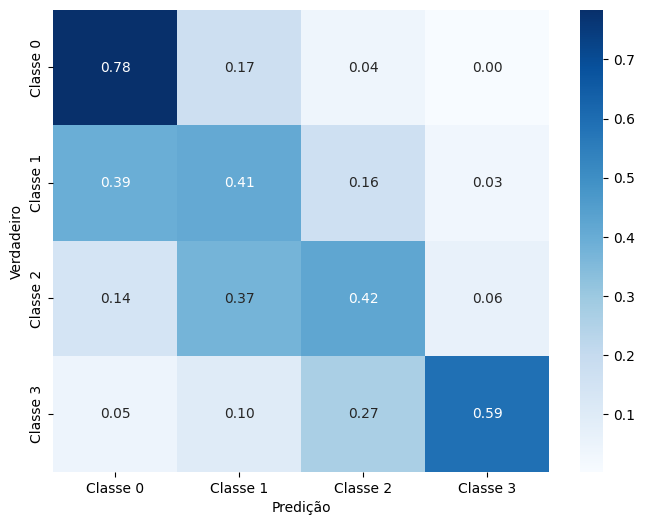

In [ ]:
y_pred = KNN.predict(x_test4)
f1 = f1_score(y_test4, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(KNN, x_test4, y_test4)

In [ ]:
XGB = XGBClassifier()
XGB.fit(x_train4, y_train4)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

F1 - Score: 0.7658515155462676


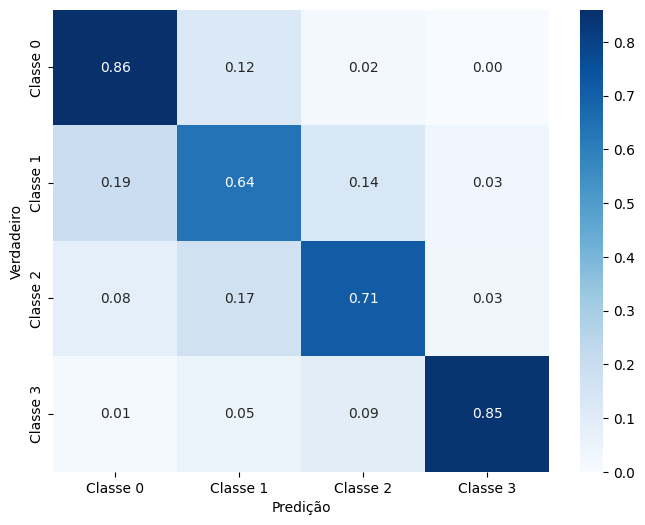

In [ ]:
y_pred = XGB.predict(x_test4)
f1 = f1_score(y_test4, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(XGB, x_test4, y_test4)

In [ ]:
DT = DecisionTreeClassifier()
DT.fit(x_train4, y_train4)

DecisionTreeClassifier()

F1 - Score: 0.656714173910886


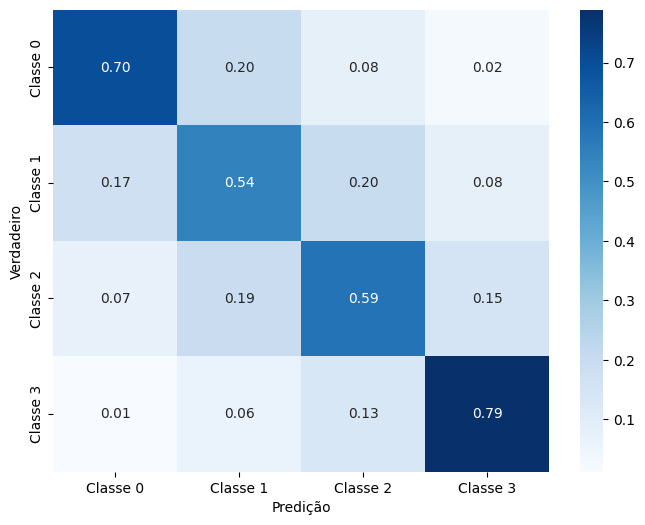

In [ ]:
y_pred = DT.predict(x_test4)
f1 = f1_score(y_test4, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(DT, x_test4, y_test4)

In [ ]:
RF = RandomForestClassifier()
RF.fit(x_train4, y_train4)

RandomForestClassifier()

F1 - Score: 0.7435220859979231


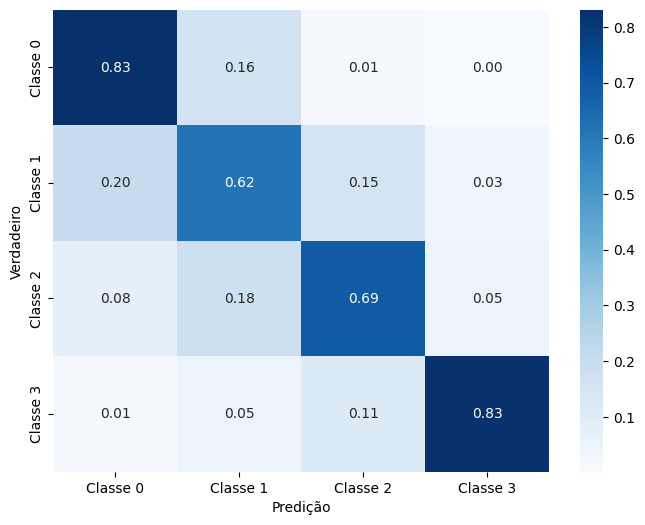

In [ ]:
y_pred = RF.predict(x_test4)
f1 = f1_score(y_test4, y_pred, average='weighted')

print("F1 - Score:", f1)
confusao2(RF, x_test4, y_test4)

Os modelos se mantiveram basicamente iguais.